In [1]:
import os
import wfdb

# Path to your extracted folder
database_path = r"C:\Users\User\apnea-ecg-database-1.0.0\apnea-ecg-database-1.0.0\\"

# Verify the folder exists
if not os.path.exists(database_path):
    raise FileNotFoundError(f"Directory not found: {database_path}")

# List files in the folder
print("Files in directory:", os.listdir(database_path)) 

Files in directory: ['a01.apn', 'a01.dat', 'a01.hea', 'a01.qrs', 'a01.xws', 'a01er.apn', 'a01er.hea', 'a01er.qrs', 'a01er.xws', 'a01r.apn', 'a01r.dat', 'a01r.hea', 'a02.apn', 'a02.dat', 'a02.hea', 'a02.qrs', 'a02.xws', 'a02er.apn', 'a02er.hea', 'a02er.qrs', 'a02er.xws', 'a02r.apn', 'a02r.dat', 'a02r.hea', 'a03.apn', 'a03.dat', 'a03.hea', 'a03.qrs', 'a03.xws', 'a03er.apn', 'a03er.hea', 'a03er.qrs', 'a03er.xws', 'a03r.apn', 'a03r.dat', 'a03r.hea', 'a04.apn', 'a04.dat', 'a04.hea', 'a04.qrs', 'a04.xws', 'a04er.apn', 'a04er.hea', 'a04er.qrs', 'a04er.xws', 'a04r.apn', 'a04r.dat', 'a04r.hea', 'a05.apn', 'a05.dat', 'a05.hea', 'a05.qrs', 'a05.xws', 'a06.apn', 'a06.dat', 'a06.hea', 'a06.qrs', 'a06.xws', 'a07.apn', 'a07.dat', 'a07.hea', 'a07.qrs', 'a07.xws', 'a08.apn', 'a08.dat', 'a08.hea', 'a08.qrs', 'a08.xws', 'a09.apn', 'a09.dat', 'a09.hea', 'a09.qrs', 'a09.xws', 'a10.apn', 'a10.dat', 'a10.hea', 'a10.qrs', 'a10.xws', 'a11.apn', 'a11.dat', 'a11.hea', 'a11.qrs', 'a11.xws', 'a12.apn', 'a12.dat', 

In [2]:
import wfdb
import numpy as np
import matplotlib.pyplot as plt
from biosppy.signals import ecg
record_name = 'a01'

def load_record(record_name, database_path):
    # Load ECG
    record_path = os.path.join(database_path, record_name)
    record = wfdb.rdrecord(record_path)
    ecg_signal = record.p_signal[:, 0]  # Assuming single-lead ECG

    # Load apnea annotations (1 per minute)
    annotation = wfdb.rdann(record_path, 'apn')
    labels = annotation.symbol  # 'A' for apnea, 'N' for normal

    return ecg_signal, labels

In [3]:
def segment_ecg(ecg_signal, window_size=6000):
    segments = []
    for i in range(0, len(ecg_signal), window_size):
        segment = ecg_signal[i:i+window_size]
        if len(segment) == window_size:
            segments.append(segment)
    return np.array(segments)


In [4]:
def process_record(record_name, database_path):
    ecg, labels = load_record(record_name, database_path)
    segments = segment_ecg(ecg)
    labels = labels[:len(segments)]  # Truncate to match segments
    return segments, labels


In [5]:
segments, labels = process_record('a01', database_path)

print(f"Total segments: {len(segments)}")
print(f"First label: {labels[0]}")  # 'A' or 'N'


Total segments: 492
First label: N


In [6]:
import matplotlib.pyplot as plt

def plot_ecg_segment(segment, label, record_name, segment_index, fs=100):
    time = np.linspace(0, 60, len(segment))  # 60 seconds, fs=100 Hz
    plt.figure(figsize=(12, 4))
    plt.plot(time, segment, label='ECG')
    plt.title(f"{record_name.upper()} - Segment {segment_index+1} | Label: {'Apnea' if label=='A' else 'Normal'}")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude (mV)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


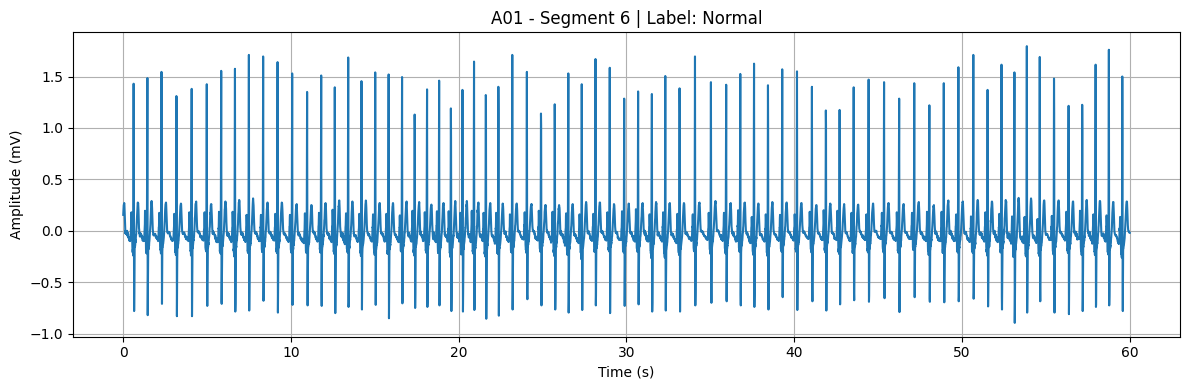

In [7]:
plot_ecg_segment(segments[5], labels[2], 'a01', 5)


In [9]:
import neurokit2 as nk
import scipy.stats as stats

def extract_features_from_segment(ecg_segment, fs=100):
    # Preprocess and get R-peaks
    try:
        ecg_cleaned = nk.ecg_clean(ecg_segment, sampling_rate=fs)
        _, rpeaks = nk.ecg_peaks(ecg_cleaned, sampling_rate=fs)
        rr_intervals = np.diff(rpeaks['ECG_R_Peaks']) / fs  # in seconds

        if len(rr_intervals) < 2:
            return None  # Not enough RR data

        # Time-domain HRV features
        mean_rr = np.mean(rr_intervals)
        median_rr = np.median(rr_intervals)
        mode_rr = stats.mode(rr_intervals, keepdims=False).mode
        sdnn = np.std(rr_intervals)
        rmssd = np.sqrt(np.mean(np.square(np.diff(rr_intervals))))
        pnn50 = np.sum(np.abs(np.diff(rr_intervals)) > 0.05) / len(rr_intervals) * 100
        min_rr = np.min(rr_intervals)
        max_rr = np.max(rr_intervals)

        # Non-linear RR features
        diff_rr = np.diff(rr_intervals)
        mean_diff = np.mean(diff_rr)
        var_diff = np.var(diff_rr)
        skew_rr = stats.skew(rr_intervals)
        kurt_rr = stats.kurtosis(rr_intervals)
        entropy_rr = stats.entropy(np.histogram(rr_intervals, bins=10)[0] + 1)

        # Morphological features
        r_peaks = rpeaks["ECG_R_Peaks"]
        r_amplitudes = ecg_cleaned[r_peaks]
        mean_r_amp = np.mean(r_amplitudes)
        std_r_amp = np.std(r_amplitudes)
        min_r_amp = np.min(r_amplitudes)
        max_r_amp = np.max(r_amplitudes)
        qrs_width = np.mean(np.diff(r_peaks)) / fs  # Approx.
        hr = 60 / mean_rr
        hr_var = np.var(60 / rr_intervals)
        hr_max = np.max(60 / rr_intervals)

        # Statistical features of raw ECG
        mean_ecg = np.mean(ecg_segment)
        median_ecg = np.median(ecg_segment)
        mode_ecg = stats.mode(ecg_segment, keepdims=False).mode
        var_ecg = np.var(ecg_segment)
        skew_ecg = stats.skew(ecg_segment)
        kurt_ecg = stats.kurtosis(ecg_segment)

        return [
            mean_rr, median_rr, mode_rr, sdnn, rmssd, pnn50, min_rr, max_rr,
            mean_diff, var_diff, skew_rr, kurt_rr, entropy_rr,
            mean_r_amp, std_r_amp, min_r_amp, max_r_amp, qrs_width, hr, hr_var, hr_max,
            mean_ecg, median_ecg, mode_ecg, var_ecg, skew_ecg, kurt_ecg
        ]
    except Exception as e:
        print(f"Error in feature extraction: {e}")
        return None


In [10]:
features_list = []

for i in range(len(segments)):
    features = extract_features_from_segment(segments[i])
    if features:
        features_list.append(features)

print(f"Extracted features for {len(features_list)} segments.")


Extracted features for 492 segments.


In [11]:
# Truncate to match labels length
segments = segments[:len(labels)]


In [12]:
features_list = []
filtered_labels = []

for i in range(len(segments)):
    features = extract_features_from_segment(segments[i])
    if features:
        features_list.append(features)
        filtered_labels.append(labels[i])
    else:
        print(f"Skipping segment {i} due to extraction failure.")


In [13]:
import pandas as pd

df = pd.DataFrame(features_list)
df['label'] = labels[:len(df)]
df.to_csv("a01_features.csv", index=False)

In [14]:
import os
import wfdb
import numpy as np
import pandas as pd
import neurokit2 as nk
import scipy.stats as stats

# Set your path to PhysioNet database

database_path = r"C:\Users\User\apnea-ecg-database-1.0.0\apnea-ecg-database-1.0.0\\"
# Training set records (as per your project)
records = [
    'a01', 'a02', 'a03', 'a04', 'a05', 'a06', 'a07', 'a08', 'a09', 'a10',
    'a11', 'a12', 'a13', 'a14', 'a15', 'a16', 'a17', 'a18', 'a19', 'a20',
    'b01', 'b02', 'b03', 'b04', 'b05',
    'c01', 'c02', 'c03', 'c04', 'c05', 'c06', 'c07', 'c08', 'c09', 'c10'
]

def segment_ecg(ecg_signal, window_size=6000):
    return np.array([ecg_signal[i:i+window_size] for i in range(0, len(ecg_signal), window_size)
                     if len(ecg_signal[i:i+window_size]) == window_size])

def extract_features_from_segment(ecg_segment, fs=100):
    try:
        ecg_cleaned = nk.ecg_clean(ecg_segment, sampling_rate=fs)
        _, rpeaks = nk.ecg_peaks(ecg_cleaned, sampling_rate=fs)
        rr_intervals = np.diff(rpeaks['ECG_R_Peaks']) / fs

        if len(rr_intervals) < 2:
            return None

        # Time domain
        mean_rr = np.mean(rr_intervals)
        median_rr = np.median(rr_intervals)
        mode_rr = stats.mode(rr_intervals, keepdims=False).mode
        sdnn = np.std(rr_intervals)
        rmssd = np.sqrt(np.mean(np.square(np.diff(rr_intervals))))
        pnn50 = np.sum(np.abs(np.diff(rr_intervals)) > 0.05) / len(rr_intervals) * 100
        min_rr = np.min(rr_intervals)
        max_rr = np.max(rr_intervals)

        # Nonlinear
        mean_diff = np.mean(np.diff(rr_intervals))
        var_diff = np.var(np.diff(rr_intervals))
        skew_rr = stats.skew(rr_intervals)
        kurt_rr = stats.kurtosis(rr_intervals)
        entropy_rr = stats.entropy(np.histogram(rr_intervals, bins=10)[0] + 1)

        # Morphological
        r_amps = ecg_cleaned[rpeaks["ECG_R_Peaks"]]
        mean_r_amp = np.mean(r_amps)
        std_r_amp = np.std(r_amps)
        min_r_amp = np.min(r_amps)
        max_r_amp = np.max(r_amps)
        qrs_width = np.mean(np.diff(rpeaks["ECG_R_Peaks"])) / fs
        hr = 60 / mean_rr
        hr_var = np.var(60 / rr_intervals)
        hr_max = np.max(60 / rr_intervals)

        # Raw ECG statistics
        mean_ecg = np.mean(ecg_segment)
        median_ecg = np.median(ecg_segment)
        mode_ecg = stats.mode(ecg_segment, keepdims=False).mode
        var_ecg = np.var(ecg_segment)
        skew_ecg = stats.skew(ecg_segment)
        kurt_ecg = stats.kurtosis(ecg_segment)

        return [
            mean_rr, median_rr, mode_rr, sdnn, rmssd, pnn50, min_rr, max_rr,
            mean_diff, var_diff, skew_rr, kurt_rr, entropy_rr,
            mean_r_amp, std_r_amp, min_r_amp, max_r_amp, qrs_width, hr, hr_var, hr_max,
            mean_ecg, median_ecg, mode_ecg, var_ecg, skew_ecg, kurt_ecg
        ]
    except:
        return None

# Collect all features and labels
all_features = []
all_labels = []

for record in records:
    print(f"Processing {record}...")
    try:
        rec_path = os.path.join(database_path, record)
        ecg = wfdb.rdrecord(rec_path).p_signal[:, 0]
        ann = wfdb.rdann(rec_path, 'apn')
        labels = ann.symbol

        segments = segment_ecg(ecg)
        segments = segments[:len(labels)]

        for i in range(len(segments)):
            features = extract_features_from_segment(segments[i])
            if features:
                all_features.append(features)
                all_labels.append(labels[i])
    except Exception as e:
        print(f"Failed to process {record}: {e}")

# Save to DataFrame
df = pd.DataFrame(all_features)
df['label'] = all_labels
df.to_csv("apnea_ecg_features.csv", index=False)

print("✅ Feature extraction complete. Saved to 'apnea_ecg_features.csv'")


Processing a01...
Processing a02...
Processing a03...
Processing a04...
Processing a05...
Processing a06...
Processing a07...
Processing a08...
Processing a09...
Processing a10...
Processing a11...
Processing a12...
Processing a13...
Processing a14...
Processing a15...
Processing a16...
Processing a17...
Processing a18...
Processing a19...
Processing a20...
Processing b01...
Processing b02...
Processing b03...
Processing b04...
Processing b05...
Processing c01...


C:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\_core\fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\_core\_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Processing c02...
Processing c03...
Processing c04...
Processing c05...
Processing c06...
Processing c07...
Processing c08...
Processing c09...
Processing c10...
✅ Feature extraction complete. Saved to 'apnea_ecg_features.csv'


In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Load your dataset
df = pd.read_csv("apnea_ecg_features.csv")

# Encode apnea labels ('A' = Apnea, 'N' = Normal)
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['label'])  # 'N'→0, 'A'→1

# Separate features and labels
X = df.drop('label', axis=1)
y = df['label']

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)


In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Train classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Evaluate
y_pred = clf.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=['Normal', 'Apnea']))


[[1159  143]
 [ 137 1955]]
              precision    recall  f1-score   support

      Normal       0.89      0.89      0.89      1302
       Apnea       0.93      0.93      0.93      2092

    accuracy                           0.92      3394
   macro avg       0.91      0.91      0.91      3394
weighted avg       0.92      0.92      0.92      3394



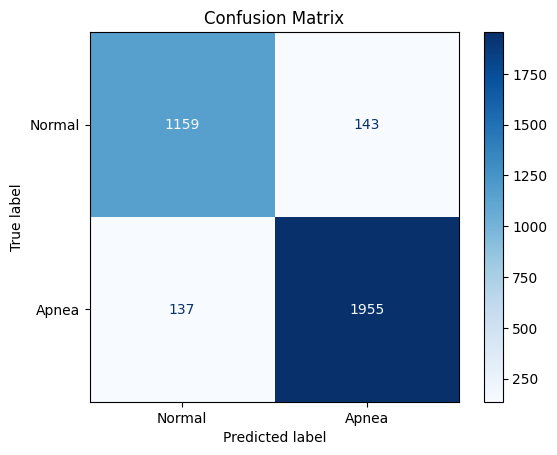

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test, display_labels=['Normal', 'Apnea'], cmap='Blues')
plt.title("Confusion Matrix")
plt.show()


In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Define a dictionary of models to try
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM (RBF Kernel)": SVC(kernel='rbf', probability=True),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100),
}

# Function to evaluate models
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
    
    results = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_proba) if y_proba is not None else "N/A"
    }
    return results

# Run and store results
results = []
for name, model in models.items():
    metrics = evaluate_model(name, model, X_train, X_test, y_train, y_test)
    results.append(metrics)

# Show results in a table
results_df = pd.DataFrame(results)
print(results_df.sort_values(by='F1 Score', ascending=False))


                 Model  Accuracy  Precision    Recall  F1 Score   ROC AUC
4        Random Forest  0.917207   0.930575  0.935468  0.933015  0.973571
2  K-Nearest Neighbors  0.890689   0.914699  0.907266  0.910967  0.943662
3        Decision Tree  0.873895   0.898849  0.896272  0.897559  0.867107
1     SVM (RBF Kernel)  0.869476   0.895444  0.892447  0.893943  0.931102
0  Logistic Regression  0.763406   0.777922  0.862333  0.817955  0.827877


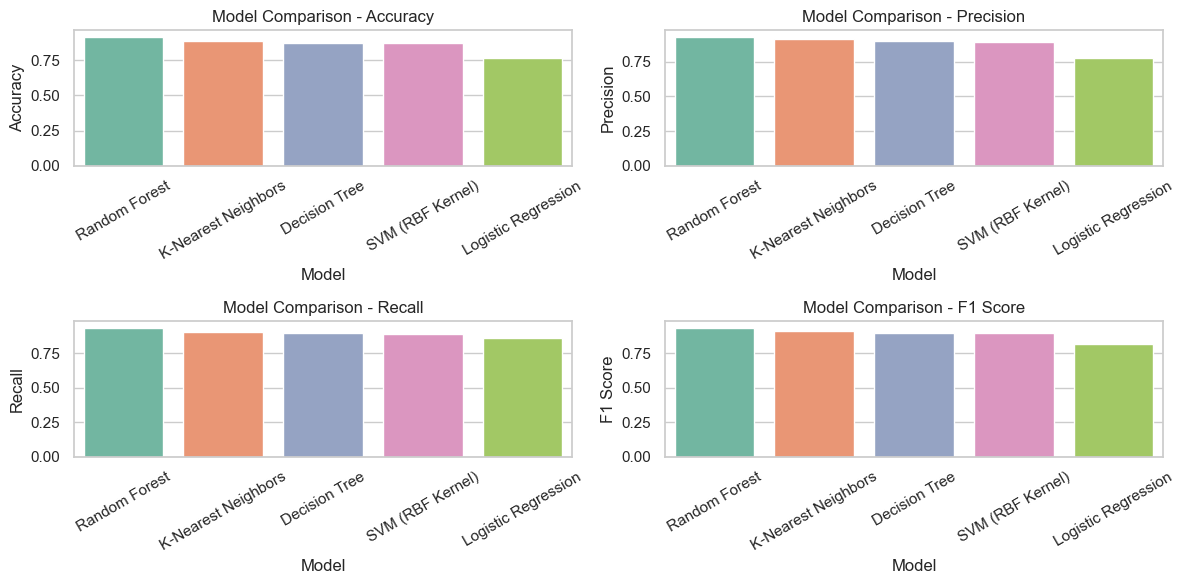

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set(style="whitegrid")

# Plot each metric
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1 Score"]

plt.figure(figsize=(12, 6))
for i, metric in enumerate(metrics_to_plot, 1):
    plt.subplot(2, 2, i)
    sns.barplot(x="Model", y=metric,hue="Model", data=results_df.sort_values(by=metric, ascending=False), palette="Set2")
    plt.title(f"Model Comparison - {metric}")
    plt.xticks(rotation=30)

plt.tight_layout()
plt.show()


In [6]:
from sklearn.model_selection import cross_val_score

cv_results = {}

for name, model in models.items():
    scores = cross_val_score(model, X_scaled, y, cv=5, scoring='f1')
    cv_results[name] = scores.mean()

cv_df = pd.DataFrame.from_dict(cv_results, orient='index', columns=['Mean F1 (CV)']).sort_values(by='Mean F1 (CV)', ascending=False)
print(cv_df)


                     Mean F1 (CV)
SVM (RBF Kernel)         0.743238
Logistic Regression      0.733839
Random Forest            0.679393
Decision Tree            0.641570
K-Nearest Neighbors      0.609488
